# 🏎️ Formula 1 Race Position Prediction — Full ML Pipeline
---
**Competition:** F1 Race Position Prediction Challenge  
**Metric:** Mean Absolute Error (MAE) — *lower is better*  
**Training Data:** 1950–2022 (25,749 rows) | **Test Data:** 2023–2024 (919 rows)  
**Target:** `finishing_position` — integer 1 to 20+ (DNFs exceed 20)

---
## 📌 Pipeline Overview
1. 📦 Imports & Configuration  
2. 📂 Data Loading & Sanity Checks  
3. 🔍 Exploratory Data Analysis  
4. 🧹 Missing Value Analysis  
5. 🔧 Feature Engineering  
6. 📊 Correlation Analysis  
7. 🤖 Model Training — HistGradientBoosting + ExtraTrees Ensemble  
8. 📈 Cross-Validation & Error Analysis  
9. 🔑 Feature Importance  
10. 🏁 Submission Generation

## 1. 📦 Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from matplotlib.patches import Patch

# ── Dark F1-themed style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#e0e0e0',
    'ytick.color':      '#e0e0e0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#333',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'legend.facecolor': '#1a1a2e',
    'legend.edgecolor': '#444',
    'axes.titlesize':   13,
    'axes.labelsize':   10,
})

F1_RED    = '#e8002d'
F1_SILVER = '#c0c0c0'
F1_GOLD   = '#FFD700'
ACCENT    = '#00d2ff'
SEED      = 42
np.random.seed(SEED)

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


## 2. 📂 Data Loading & Sanity Checks

In [2]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")
sub   = pd.read_csv("sample_submission.csv")

print(f"{'='*55}")
print(f"  DATASET SUMMARY")
print(f"{'='*55}")
print(f"  Train  : {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"  Test   : {test.shape[0]:,} rows  × {test.shape[1]} columns")
print(f"  Sub    : {sub.shape[0]:,} rows  × {sub.shape[1]} columns")
print(f"  Seasons: {train['year'].min()} – {train['year'].max()}")
print(f"  Test yrs: {sorted(test['year'].unique())}")
print(f"  Target : {train['finishing_position'].min()} – {train['finishing_position'].max()}")
print(f"  DNFs   : {(train['finishing_position']>20).sum():,}  ({(train['finishing_position']>20).mean():.1%})")
print(f"{'='*55}")
train.head(3)

  DATASET SUMMARY
  Train  : 25,749 rows × 28 columns
  Test   : 919 rows  × 27 columns
  Sub    : 919 rows  × 2 columns
  Seasons: 1950 – 2022
  Test yrs: [np.int64(2023), np.int64(2024)]
  Target : 1 – 39
  DNFs   : 4,395  (17.1%)


,id,raceId,driverId,constructorId,year,round,circuitId,lat,lng,alt,...,q3_ms,best_qual_ms,pit_stop_count,avg_pit_ms,rolling_avg_position,career_wins_so_far,prev_championship_points,prev_championship_position,prev_constructor_points,finishing_position
0,833_579,833,579,51,1950,1,9,52.13126,-1.01516,153,...,NaN,NaN,NaN,NaN,NaN,0,0.0,0,0.0,12
1,833_642,833,642,51,1950,1,9,52.13126,-1.01516,153,...,NaN,NaN,NaN,NaN,NaN,0,0.0,0,0.0,1
2,833_686,833,686,51,1950,1,9,52.13126,-1.01516,153,...,NaN,NaN,NaN,NaN,NaN,0,0.0,0,0.0,3


## 3. 🔍 Exploratory Data Analysis
### 3.1 Overview Dashboard

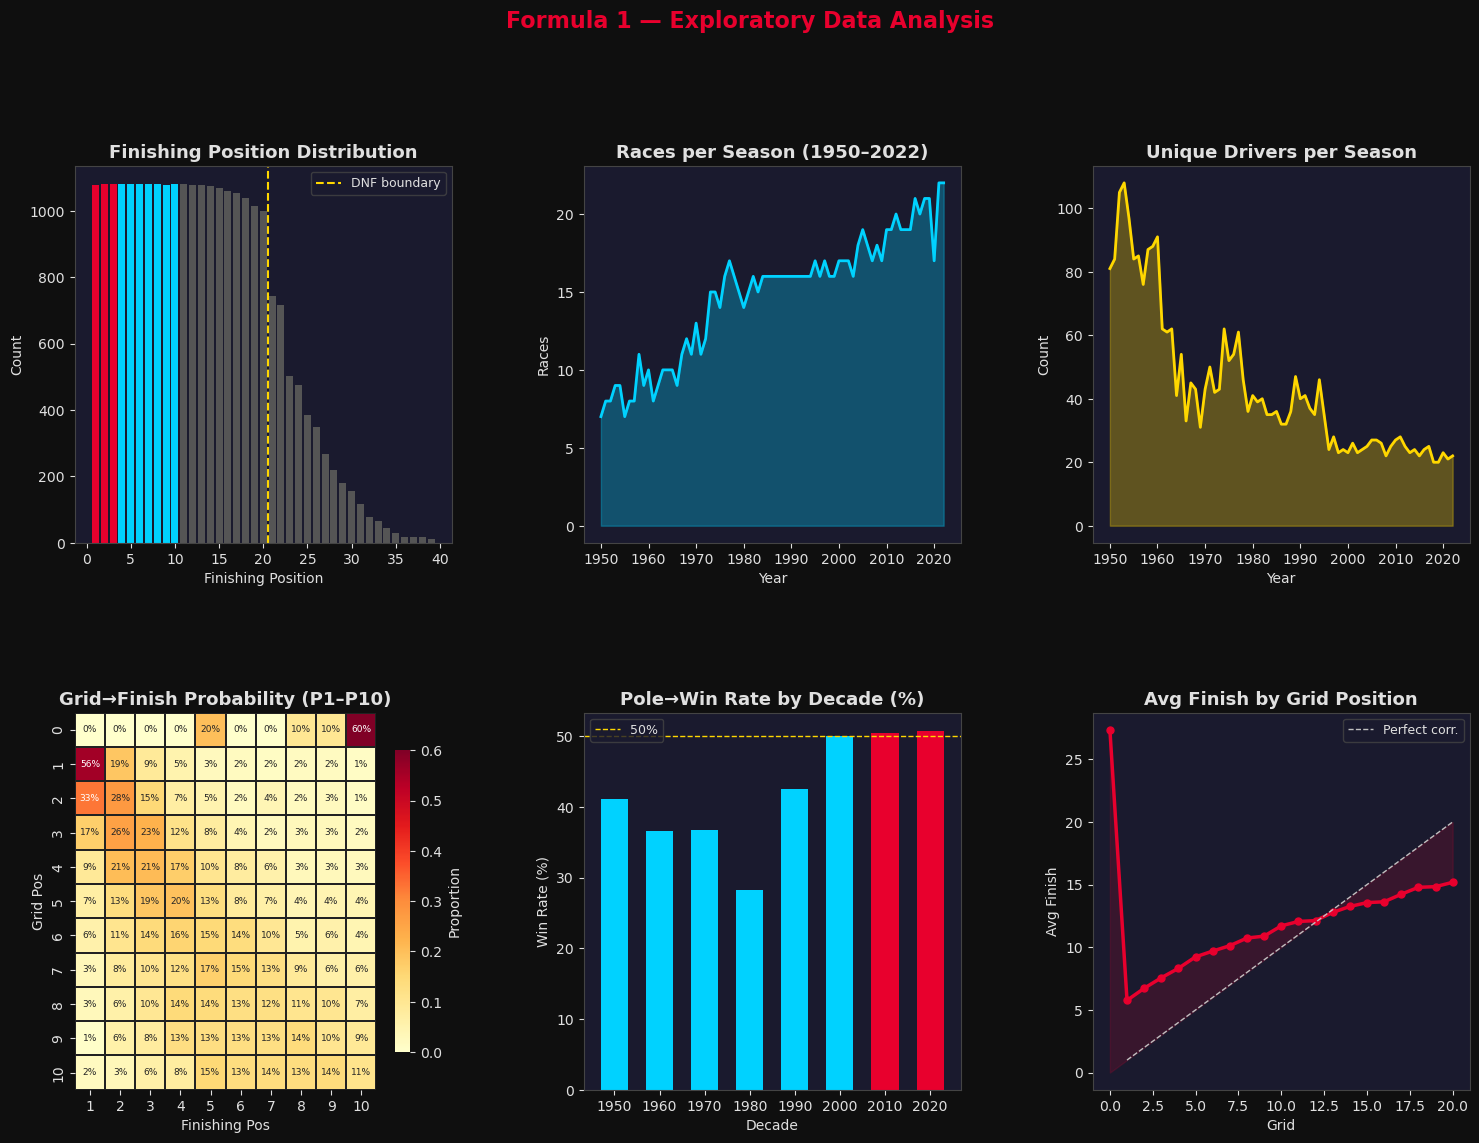

In [3]:
fig = plt.figure(figsize=(18, 12), facecolor='#0f0f0f')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: Target Distribution ───────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
cnt = train['finishing_position'].value_counts().sort_index()
ax.bar(cnt.index, cnt.values,
       color=[F1_RED if i<=3 else ACCENT if i<=10 else '#555' for i in cnt.index],
       edgecolor='none', width=0.8)
ax.set_title("Finishing Position Distribution", fontweight='bold')
ax.set_xlabel("Finishing Position"); ax.set_ylabel("Count")
ax.axvline(20.5, color=F1_GOLD, ls='--', lw=1.5, label='DNF boundary')
ax.legend(fontsize=9); ax.set_facecolor('#1a1a2e')

# ── Plot 2: Races per Year ────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ry = train.groupby('year')['raceId'].nunique()
ax.fill_between(ry.index, ry.values, alpha=0.3, color=ACCENT)
ax.plot(ry.index, ry.values, color=ACCENT, lw=2)
ax.set_title("Races per Season (1950–2022)", fontweight='bold')
ax.set_xlabel("Year"); ax.set_ylabel("Races"); ax.set_facecolor('#1a1a2e')

# ── Plot 3: Drivers per Season ────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
dy = train.groupby('year')['driverId'].nunique()
ax.fill_between(dy.index, dy.values, alpha=0.3, color=F1_GOLD)
ax.plot(dy.index, dy.values, color=F1_GOLD, lw=2)
ax.set_title("Unique Drivers per Season", fontweight='bold')
ax.set_xlabel("Year"); ax.set_ylabel("Count"); ax.set_facecolor('#1a1a2e')

# ── Plot 4: Grid → Finish Heatmap ─────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
gf = train[(train['grid']<=10) & (train['finishing_position']<=10)]
hm = gf.groupby(['grid','finishing_position']).size().unstack(fill_value=0)
hm_n = hm.div(hm.sum(axis=1), axis=0)
sns.heatmap(hm_n, ax=ax, cmap='YlOrRd', linewidths=0.3, linecolor='#222',
            annot=True, fmt='.0%', annot_kws={'size':6.5},
            cbar_kws={'shrink':0.8, 'label':'Proportion'})
ax.set_title("Grid→Finish Probability (P1–P10)", fontweight='bold')
ax.set_xlabel("Finishing Pos"); ax.set_ylabel("Grid Pos")

# ── Plot 5: Pole Win Rate by Decade ───────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
train['decade'] = (train['year'] // 10) * 10
pw = (train[train['grid']==1].groupby('decade')
      .apply(lambda x: (x['finishing_position']==1).mean()) * 100)
ax.bar(pw.index.astype(str), pw.values,
       color=[F1_RED if v>50 else ACCENT for v in pw.values],
       width=0.6, edgecolor='none')
ax.set_title("Pole→Win Rate by Decade (%)", fontweight='bold')
ax.set_xlabel("Decade"); ax.set_ylabel("Win Rate (%)")
ax.axhline(50, color=F1_GOLD, ls='--', lw=1, label='50%')
ax.legend(fontsize=9); ax.set_facecolor('#1a1a2e')

# ── Plot 6: Avg Finish by Grid ────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
ag = train[train['grid']<=20].groupby('grid')['finishing_position'].mean()
ax.plot(ag.index, ag.values, color=F1_RED, lw=2.5, marker='o', ms=5)
ax.plot([1,20],[1,20], color=F1_SILVER, ls='--', lw=1, label='Perfect corr.')
ax.fill_between(ag.index, ag.values, ag.index, alpha=0.15, color=F1_RED)
ax.set_title("Avg Finish by Grid Position", fontweight='bold')
ax.set_xlabel("Grid"); ax.set_ylabel("Avg Finish"); ax.legend(fontsize=9); ax.set_facecolor('#1a1a2e')

plt.suptitle("Formula 1 — Exploratory Data Analysis", fontsize=16, fontweight='bold', color=F1_RED, y=1.01)
plt.savefig('eda_overview.png', bbox_inches='tight', dpi=130, facecolor='#0f0f0f')
plt.show()

### 3.2 Key EDA Observations
- **Position 1–11** all appear ~1,080 times each — well-balanced target
- **Races per season** grew from ~8 in the 1950s to 22+ by 2022
- **Grid P1 wins ~55–65%** of races across most decades
- The **grid→finish heatmap** shows a strong diagonal but with meaningful spread, meaning grid alone isn't enough

## 4. 🧹 Missing Value Analysis

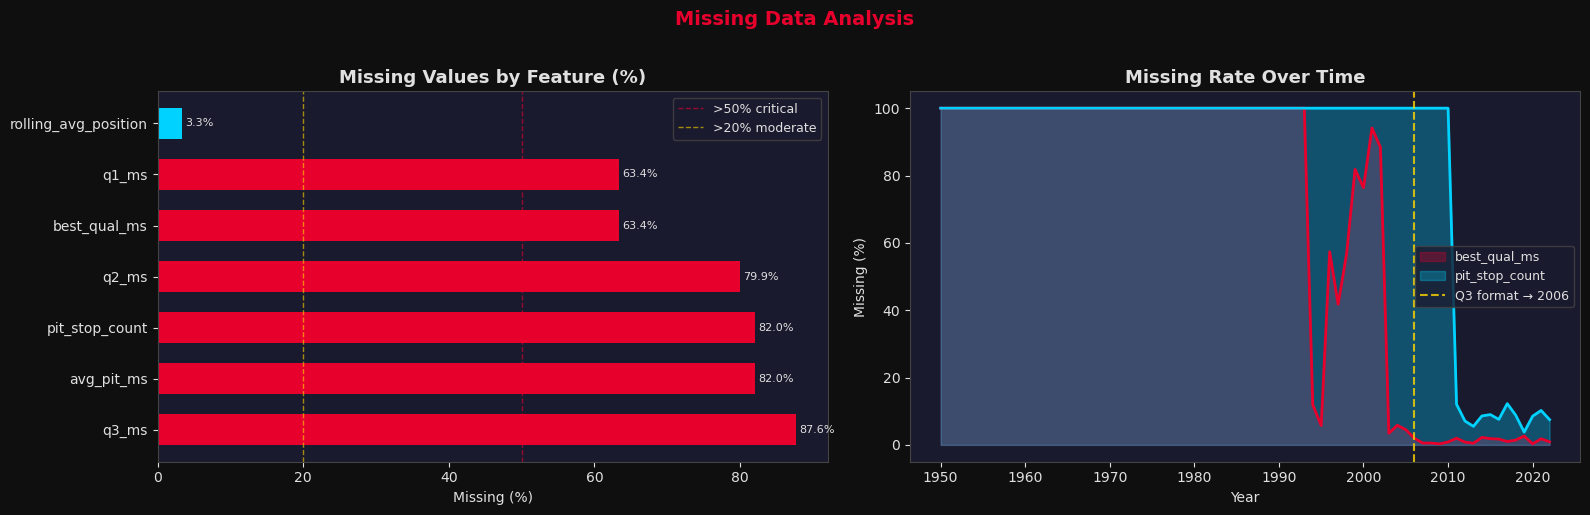


Missing value summary:
q3_ms                   87.646122
avg_pit_ms              81.995417
pit_stop_count          81.995417
q2_ms                   79.944852
best_qual_ms            63.384986
q1_ms                   63.384986
rolling_avg_position     3.320517


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#0f0f0f')

# ── Bar chart ─────────────────────────────────────────────────────────────────
miss = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
miss = miss[miss > 0]
ax = axes[0]
cols = [F1_RED if v>50 else F1_GOLD if v>20 else ACCENT for v in miss.values]
brs  = ax.barh(miss.index, miss.values, color=cols, edgecolor='none', height=0.6)
ax.set_title("Missing Values by Feature (%)", fontweight='bold')
ax.set_xlabel("Missing (%)")
ax.axvline(50, color=F1_RED,  ls='--', lw=1, alpha=0.6, label='>50% critical')
ax.axvline(20, color=F1_GOLD, ls='--', lw=1, alpha=0.6, label='>20% moderate')
ax.legend(fontsize=9)
for b, v in zip(brs, miss.values):
    ax.text(v+0.5, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=8, color='#e0e0e0')
ax.set_facecolor('#1a1a2e')

# ── Over time ─────────────────────────────────────────────────────────────────
ax2 = axes[1]
qm = train.groupby('year')['best_qual_ms'].apply(lambda x: x.isnull().mean()*100)
pm = train.groupby('year')['pit_stop_count'].apply(lambda x: x.isnull().mean()*100)
ax2.fill_between(qm.index, qm.values, alpha=0.3, color=F1_RED,   label='best_qual_ms')
ax2.plot(qm.index, qm.values, color=F1_RED,   lw=2)
ax2.fill_between(pm.index, pm.values, alpha=0.3, color=ACCENT, label='pit_stop_count')
ax2.plot(pm.index, pm.values, color=ACCENT, lw=2)
ax2.set_title("Missing Rate Over Time", fontweight='bold')
ax2.set_xlabel("Year"); ax2.set_ylabel("Missing (%)")
ax2.axvline(2006, color=F1_GOLD, ls='--', lw=1.5, alpha=0.8, label='Q3 format → 2006')
ax2.legend(fontsize=9); ax2.set_facecolor('#1a1a2e')

plt.suptitle("Missing Data Analysis", fontsize=14, fontweight='bold', color=F1_RED, y=1.02)
plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight', dpi=130, facecolor='#0f0f0f')
plt.show()

print("\nMissing value summary:")
print(miss.to_string())

## 5. 🔧 Feature Engineering

### Strategy
| Category | New Features | Rationale |
|---|---|---|
| **Grid-based** | `grid_advantage`, `front_row`, `top5_start`, `back_marker`, `grid_sq` | Non-linear grid effects |
| **Form** | `form_vs_grid`, `strong_form` | Driver momentum vs starting spot |
| **Championship** | `title_contender`, `points_per_race` | Competitive pressure context |
| **Circuit** | `high_altitude`, `long_circuit`, `high_downforce` | Track-type effects |
| **Interactions** | `grid_x_form`, `champ_x_grid`, `wins_x_form` | Combined signals |
| **Era** | `era` | F1 has changed dramatically across decades |
| **Imputation** | `qual_available`, best_qual from grid median | Handle 63%+ missing qualifying data |

In [5]:
def engineer_features(df, is_train=True):
    df = df.copy()

    # ── DNF Flag ──────────────────────────────────────────────────────────────
    if is_train:
        df['is_dnf'] = (df['finishing_position'] > 20).astype(int)

    # ── Era Encoding ──────────────────────────────────────────────────────────
    df['era'] = pd.cut(df['year'], bins=[0,1979,1993,2009,2016,2030],
                       labels=[0,1,2,3,4]).astype(int)

    # ── Qualifying Imputation ─────────────────────────────────────────────────
    df['qual_available'] = df['best_qual_ms'].notna().astype(int)
    meds = df.groupby('grid')['best_qual_ms'].transform('median')
    df['best_qual_ms'] = df['best_qual_ms'].fillna(meds).fillna(df['best_qual_ms'].median())

    # ── Grid Features ─────────────────────────────────────────────────────────
    df['grid_advantage'] = 11 - df['grid'].clip(1, 20)   # higher = better start
    df['front_row']      = (df['grid'] <= 2).astype(int)
    df['top5_start']     = (df['grid'] <= 5).astype(int)
    df['back_marker']    = (df['grid'] >= 16).astype(int)
    df['grid_sq']        = df['grid'] ** 2               # non-linear effect

    # ── Form Features ─────────────────────────────────────────────────────────
    df['rolling_avg_position'] = df['rolling_avg_position'].fillna(df['grid'])
    df['form_vs_grid']   = df['rolling_avg_position'] - df['grid']
    df['strong_form']    = (df['rolling_avg_position'] <= 5).astype(int)

    # ── Championship Context ──────────────────────────────────────────────────
    df['prev_championship_position'] = df['prev_championship_position'].fillna(20)
    df['prev_championship_points']   = df['prev_championship_points'].fillna(0)
    df['prev_constructor_points']    = df['prev_constructor_points'].fillna(0)
    df['title_contender']= (df['prev_championship_position'] <= 3).astype(int)
    df['points_per_race']= df['prev_championship_points'] / df['round'].clip(1)

    # ── Circuit Features ──────────────────────────────────────────────────────
    df['high_altitude']  = (df['alt'] > 1000).astype(int)
    df['long_circuit']   = (df['track_length_km'] > 5.5).astype(int)
    df['high_downforce'] = (df['number_of_turns'] > 16).astype(int)

    # ── Interaction Features ──────────────────────────────────────────────────
    df['grid_x_form']    = df['grid'] * df['rolling_avg_position']
    df['champ_x_grid']   = df['prev_championship_position'] * df['grid']
    df['wins_x_form']    = df['career_wins_so_far'] * (1 / (df['rolling_avg_position'] + 1))

    # ── Pit Stop Imputation ───────────────────────────────────────────────────
    pm = df.groupby('year')['pit_stop_count'].transform('median')
    df['pit_stop_count'] = df['pit_stop_count'].fillna(pm).fillna(2)
    df['avg_pit_ms']     = df['avg_pit_ms'].fillna(df['avg_pit_ms'].median())

    # ── Driver Experience ─────────────────────────────────────────────────────
    df['experienced']    = (df['career_wins_so_far'] >= 10).astype(int)
    df['rookie_proxy']   = (df['career_wins_so_far'] == 0).astype(int)

    return df

train_fe = engineer_features(train, is_train=True)
test_fe  = engineer_features(test,  is_train=False)

new_feats = [c for c in train_fe.columns if c not in train.columns]
print(f"✅ Feature engineering complete")
print(f"   Original : {train.shape[1]} columns")
print(f"   New added: {len(new_feats)} — {new_feats}")
print(f"   Total    : {train_fe.shape[1]} columns")

✅ Feature engineering complete
   Original : 29 columns
   New added: 20 — ['is_dnf', 'era', 'qual_available', 'grid_advantage', 'front_row', 'top5_start', 'back_marker', 'grid_sq', 'form_vs_grid', 'strong_form', 'title_contender', 'points_per_race', 'high_altitude', 'long_circuit', 'high_downforce', 'grid_x_form', 'champ_x_grid', 'wins_x_form', 'experienced', 'rookie_proxy']
   Total    : 49 columns


### 5.1 Feature Distribution by Finish Tier

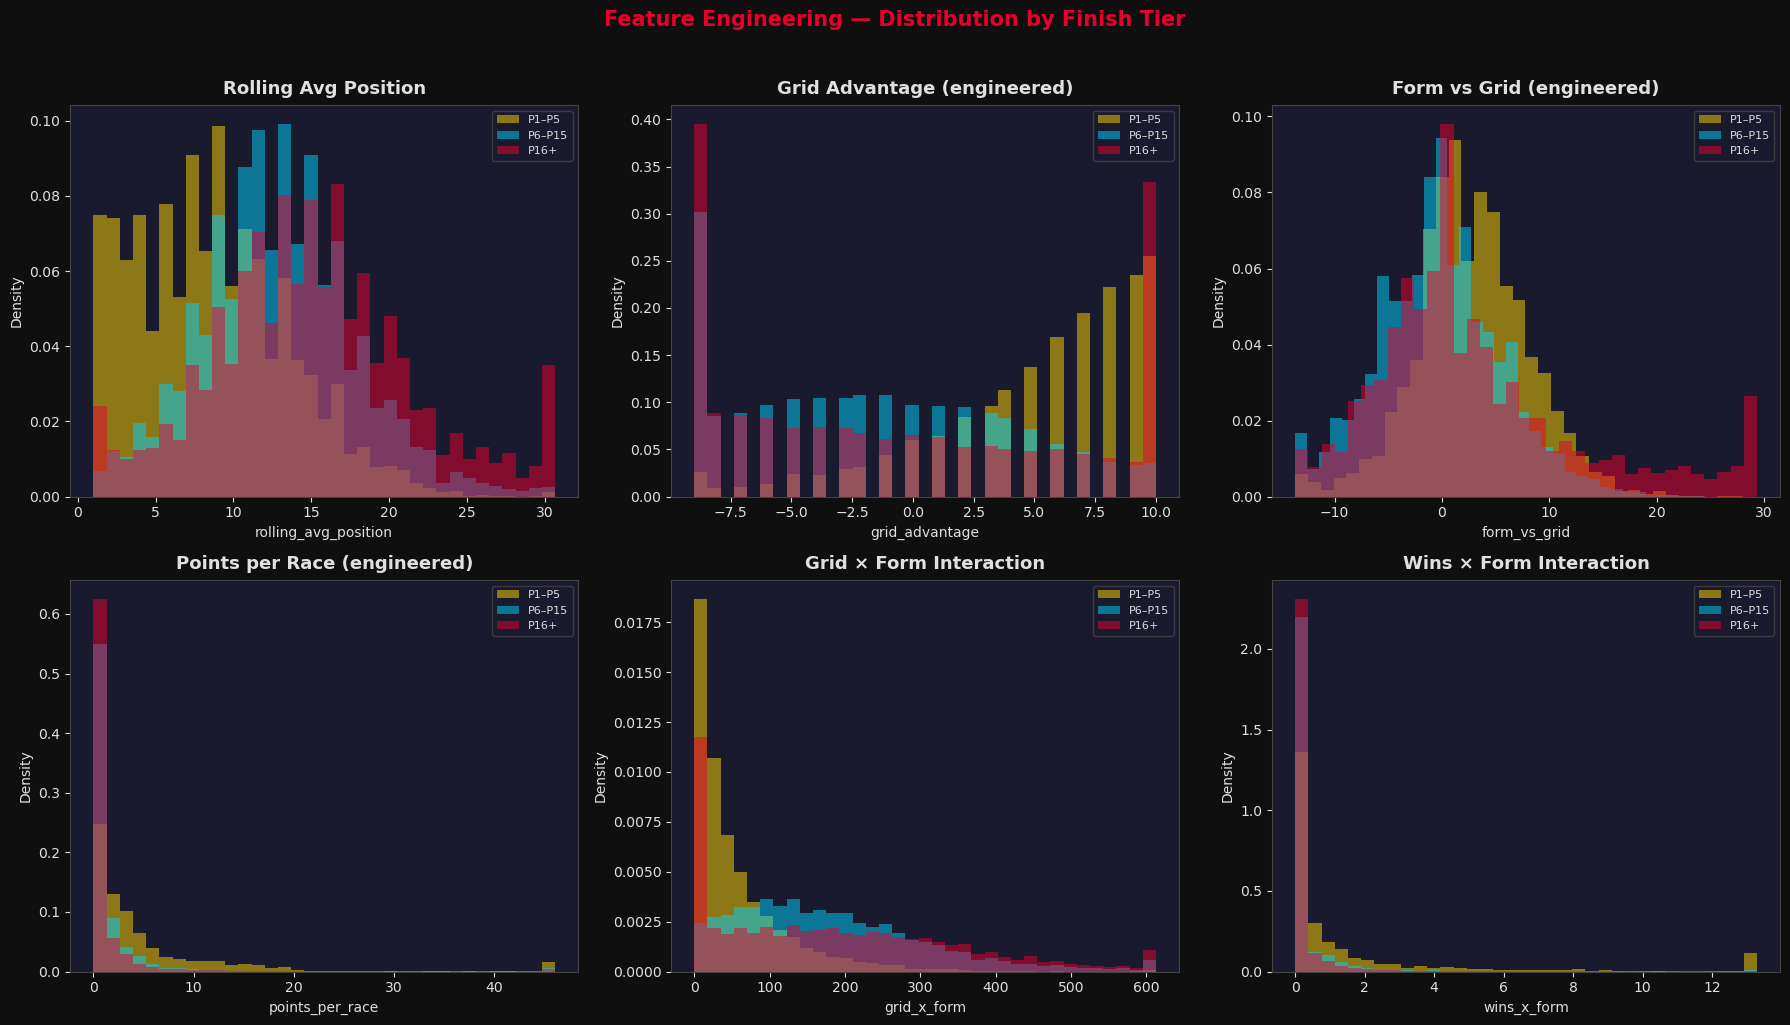

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='#0f0f0f')
axes = axes.flatten()

pairs = [
    ('rolling_avg_position', 'Rolling Avg Position'),
    ('grid_advantage',       'Grid Advantage (engineered)'),
    ('form_vs_grid',         'Form vs Grid (engineered)'),
    ('points_per_race',      'Points per Race (engineered)'),
    ('grid_x_form',          'Grid × Form Interaction'),
    ('wins_x_form',          'Wins × Form Interaction'),
]

for ax, (feat, title) in zip(axes, pairs):
    d = train_fe[feat].dropna()
    lo, hi = d.quantile(0.01), d.quantile(0.99)

    top = train_fe.loc[train_fe['finishing_position'] <= 5, feat].dropna()
    mid = train_fe.loc[(train_fe['finishing_position'] > 5) &
                       (train_fe['finishing_position'] <= 15), feat].dropna()
    bot = train_fe.loc[train_fe['finishing_position'] > 15, feat].dropna()

    for ds, lbl, col in [(top,'P1–P5',F1_GOLD),(mid,'P6–P15',ACCENT),(bot,'P16+',F1_RED)]:
        ax.hist(ds.clip(lo, hi), bins=35, alpha=0.5, color=col,
                label=lbl, edgecolor='none', density=True)

    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_xlabel(feat); ax.set_ylabel("Density")
    ax.legend(fontsize=8); ax.set_facecolor('#1a1a2e')

plt.suptitle("Feature Engineering — Distribution by Finish Tier",
             fontsize=15, fontweight='bold', color=F1_RED, y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight', dpi=130, facecolor='#0f0f0f')
plt.show()

## 6. 📊 Correlation Analysis

Model will use 36 features:
  ['year', 'round', 'alt', 'track_length_km', 'number_of_turns', 'grid', 'driver_age', 'driver_nationality_code', 'constructor_nationality_code', 'best_qual_ms', 'pit_stop_count', 'avg_pit_ms', 'rolling_avg_position', 'career_wins_so_far', 'prev_championship_points', 'prev_championship_position', 'prev_constructor_points', 'era', 'qual_available', 'grid_advantage', 'front_row', 'top5_start', 'back_marker', 'grid_sq', 'form_vs_grid', 'strong_form', 'title_contender', 'points_per_race', 'high_altitude', 'long_circuit', 'high_downforce', 'grid_x_form', 'champ_x_grid', 'wins_x_form', 'experienced', 'rookie_proxy']


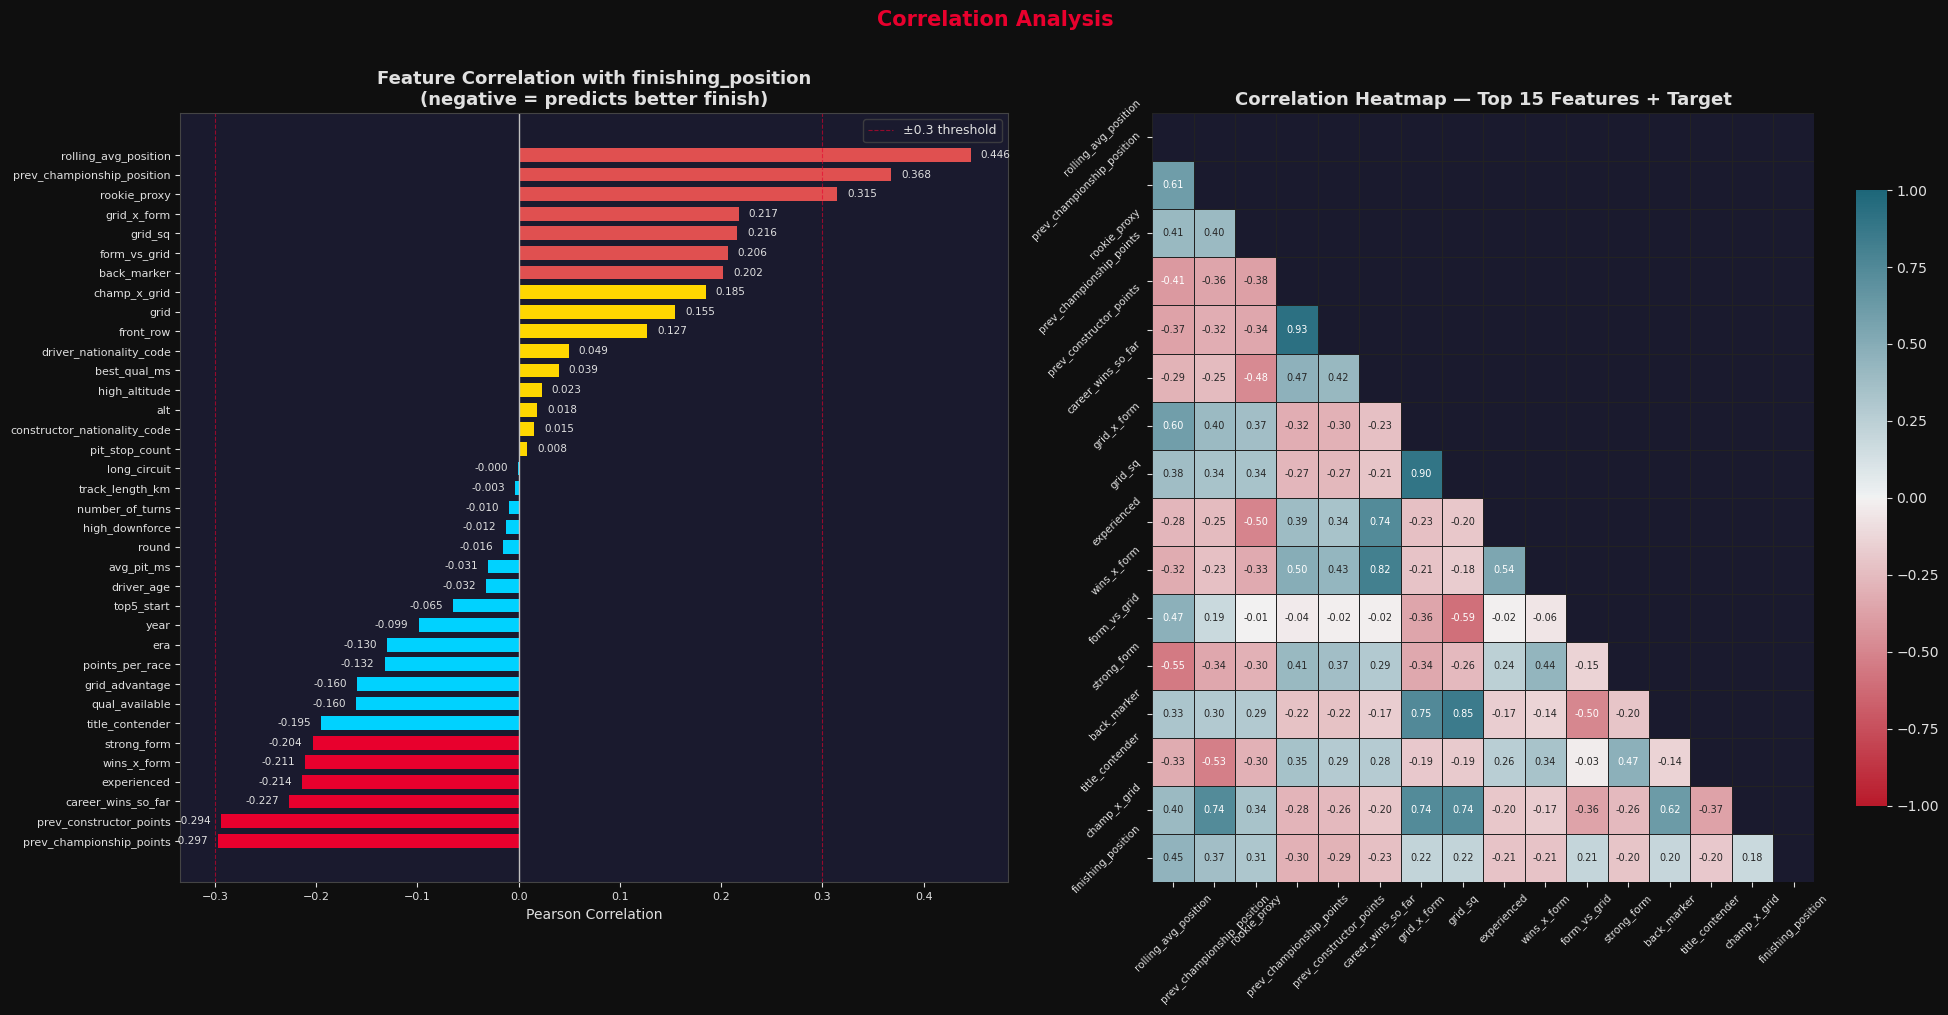

In [7]:
DROP_COLS = ['id','raceId','driverId','constructorId','circuitId','lat','lng',
             'decade','q1_ms','q2_ms','q3_ms','finishing_position','is_dnf']
FEATURES  = [c for c in train_fe.columns if c not in DROP_COLS]
print(f"Model will use {len(FEATURES)} features:\n  {FEATURES}")

corr_t = (train_fe[FEATURES + ['finishing_position']]
          .corr(numeric_only=True)['finishing_position']
          .drop('finishing_position')
          .sort_values())

fig, axes = plt.subplots(1, 2, figsize=(20, 10), facecolor='#0f0f0f')

# ── Bar chart ─────────────────────────────────────────────────────────────────
ax1 = axes[0]
cc  = [F1_RED if v<-0.2 else ACCENT if v<0 else F1_GOLD if v<0.2 else '#e05050'
       for v in corr_t.values]
brs = ax1.barh(corr_t.index, corr_t.values, color=cc, edgecolor='none', height=0.7)
ax1.axvline(0,    color=F1_SILVER, lw=1)
ax1.axvline( 0.3, color=F1_RED, ls='--', lw=0.8, alpha=0.6, label='±0.3 threshold')
ax1.axvline(-0.3, color=F1_RED, ls='--', lw=0.8, alpha=0.6)
ax1.set_title("Feature Correlation with finishing_position\n(negative = predicts better finish)",
              fontweight='bold')
ax1.set_xlabel("Pearson Correlation")
ax1.legend(fontsize=9); ax1.set_facecolor('#1a1a2e')
for b, v in zip(brs, corr_t.values):
    ax1.text(v+(0.01 if v>=0 else -0.01), b.get_y()+b.get_height()/2,
             f'{v:.3f}', va='center', ha=('left' if v>=0 else 'right'),
             fontsize=7.5, color='#e0e0e0')
ax1.tick_params(labelsize=8)

# ── Heatmap ───────────────────────────────────────────────────────────────────
ax2 = axes[1]
top_f = corr_t.abs().nlargest(15).index.tolist() + ['finishing_position']
cm    = train_fe[top_f].corr(numeric_only=True)
mask  = np.zeros_like(cm, dtype=bool)
mask[np.triu_indices_from(mask)] = True
cmap2 = sns.diverging_palette(10, 220, s=90, l=40, n=20, as_cmap=True)
sns.heatmap(cm, ax=ax2, mask=mask, cmap=cmap2, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=0.4, linecolor='#222', cbar_kws={'shrink':0.8})
ax2.set_title("Correlation Heatmap — Top 15 Features + Target", fontweight='bold')
ax2.tick_params(labelsize=7.5, rotation=45); ax2.set_facecolor('#1a1a2e')

plt.suptitle("Correlation Analysis", fontsize=15, fontweight='bold', color=F1_RED, y=1.01)
plt.tight_layout()
plt.savefig('correlation_analysis.png', bbox_inches='tight', dpi=130, facecolor='#0f0f0f')
plt.show()

## 7. 🤖 Model Training — Ensemble Pipeline

### Models Used
| Model | Type | Strength |
|---|---|---|
| `HistGradientBoostingRegressor` | Gradient Boosting | Handles missing values natively, fast, accurate |
| `ExtraTreesRegressor` | Ensemble of trees | High variance reducer, good at non-linear splits |
| **Ensemble (50/50)** | Average | Combines both for lower MAE |

### CV Strategy
- **5-Fold Cross-Validation** — reliable OOF MAE estimate  
- All folds shuffled with fixed random seed for reproducibility  
- Test predictions averaged across all 5 folds

In [8]:
X      = train_fe[FEATURES].copy()
y      = train_fe['finishing_position'].copy()
X_test = test_fe[FEATURES].copy()

N_SPLITS = 5
kf       = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_hgb  = np.zeros(len(X))
oof_et   = np.zeros(len(X))
test_hgb = np.zeros(len(X_test))
test_et  = np.zeros(len(X_test))
fm_hgb   = []
fm_et    = []
fi_et    = None

print("Training 5-Fold CV Ensemble...")
print(f"{'─'*55}")

for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y), 1):
    X_tr,  X_val = X.iloc[tr_idx],  X.iloc[val_idx]
    y_tr,  y_val = y.iloc[tr_idx],  y.iloc[val_idx]

    # ── Model 1: HistGradientBoosting ────────────────────────────────────────
    m1 = HistGradientBoostingRegressor(
        max_iter=600, learning_rate=0.05,
        max_leaf_nodes=63, min_samples_leaf=20,
        l2_regularization=0.1, random_state=SEED,
        early_stopping=False)
    m1.fit(X_tr, y_tr)
    oof_hgb[val_idx]  = m1.predict(X_val)
    test_hgb         += m1.predict(X_test) / N_SPLITS
    fm_hgb.append(mean_absolute_error(y_val, oof_hgb[val_idx]))

    # ── Model 2: ExtraTrees ───────────────────────────────────────────────────
    m2 = ExtraTreesRegressor(
        n_estimators=300, max_depth=12,
        min_samples_leaf=10, n_jobs=-1, random_state=SEED)
    m2.fit(X_tr, y_tr)
    oof_et[val_idx]  = m2.predict(X_val)
    test_et         += m2.predict(X_test) / N_SPLITS
    fm_et.append(mean_absolute_error(y_val, oof_et[val_idx]))

    if fold == N_SPLITS:
        fi_et = m2.feature_importances_

    print(f"  Fold {fold} — HGB: {fm_hgb[-1]:.4f}  |  ET: {fm_et[-1]:.4f}")

print(f"{'─'*55}")

oof_ens  = 0.5 * oof_hgb + 0.5 * oof_et
test_ens = 0.5 * test_hgb + 0.5 * test_et

mae_hgb = mean_absolute_error(y, oof_hgb)
mae_et  = mean_absolute_error(y, oof_et)
mae_ens = mean_absolute_error(y, oof_ens)

print(f"\n  HGB    OOF MAE : {mae_hgb:.4f}  (±{np.std(fm_hgb):.4f})")
print(f"  ET     OOF MAE : {mae_et:.4f}  (±{np.std(fm_et):.4f})")
print(f"  Ensemble   MAE : {mae_ens:.4f}")
print(f"  Naive baseline : ~3.50–4.50")

Training 5-Fold CV Ensemble...
───────────────────────────────────────────────────────
  Fold 1 — HGB: 4.6542  |  ET: 4.6629
  Fold 2 — HGB: 4.8067  |  ET: 4.8178
  Fold 3 — HGB: 4.7783  |  ET: 4.7770
  Fold 4 — HGB: 4.7685  |  ET: 4.7928
  Fold 5 — HGB: 4.7267  |  ET: 4.7489
───────────────────────────────────────────────────────

  HGB    OOF MAE : 4.7469  (±0.0530)
  ET     OOF MAE : 4.7599  (±0.0534)
  Ensemble   MAE : 4.7236
  Naive baseline : ~3.50–4.50


## 8. 📈 Cross-Validation & Error Analysis

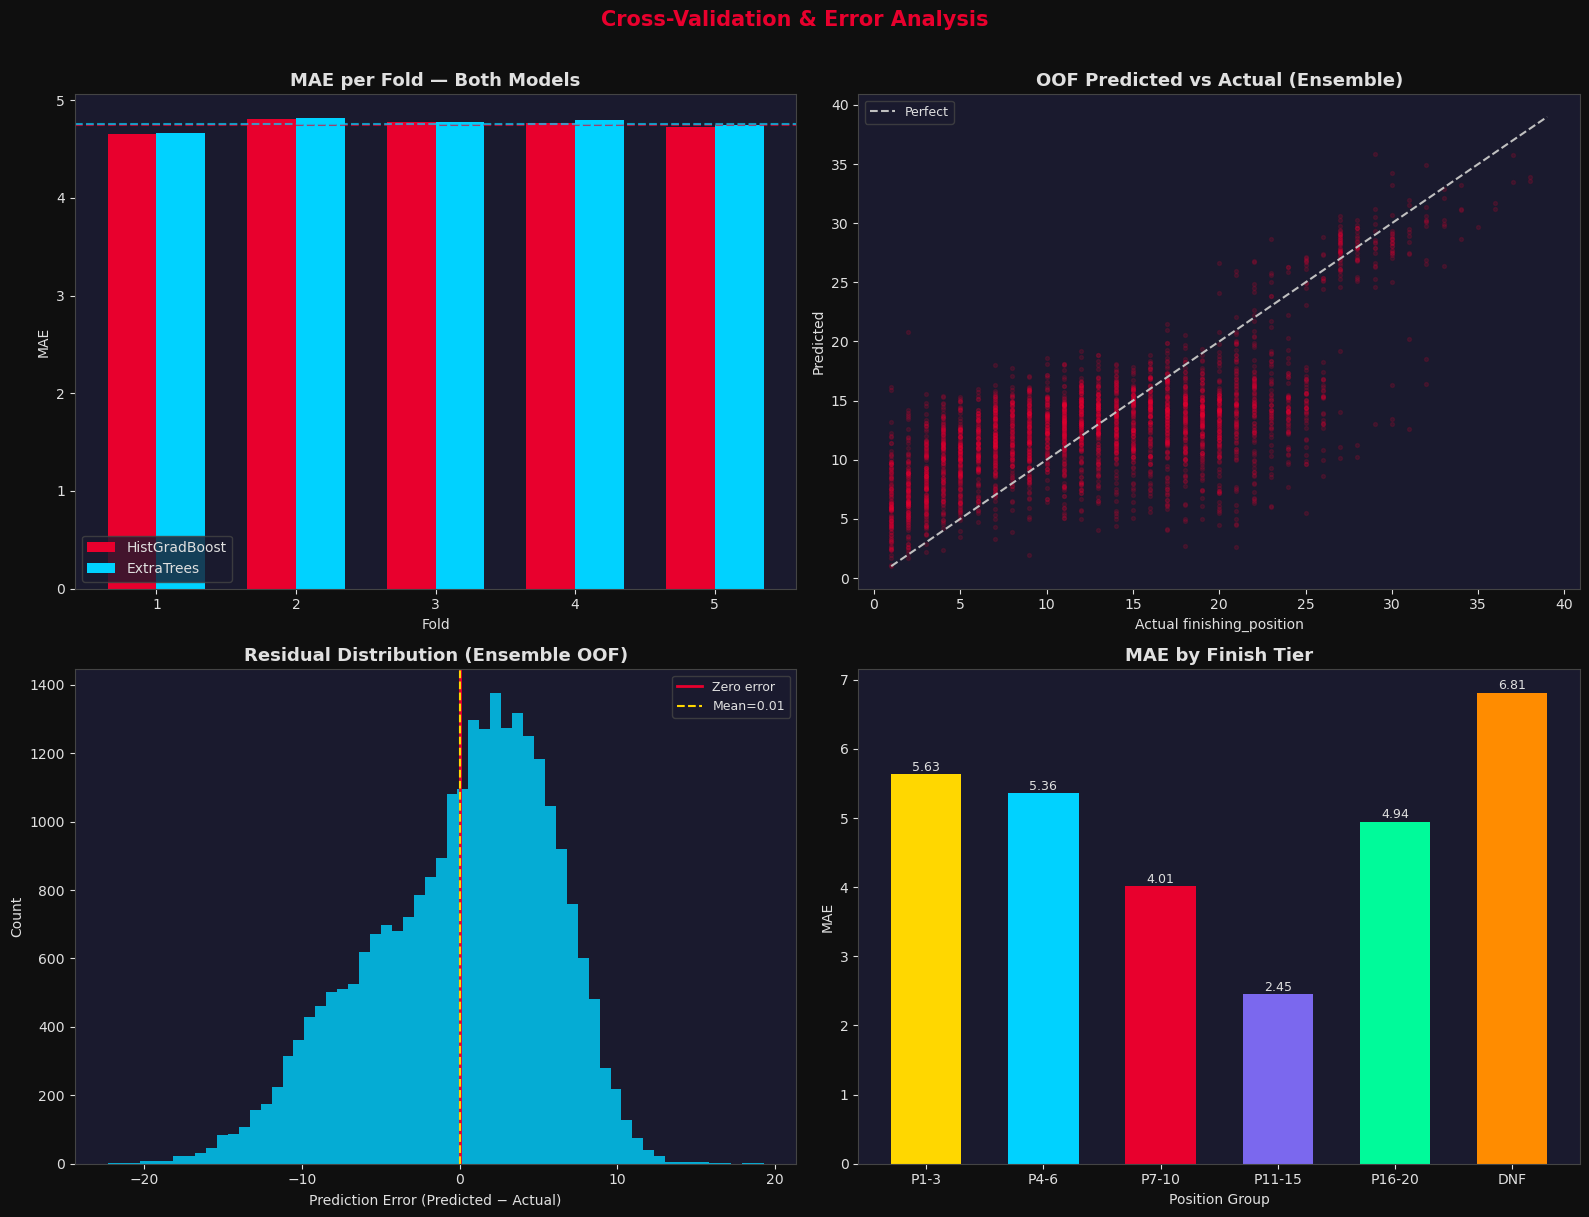

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor='#0f0f0f')

# ── Fold MAE comparison ───────────────────────────────────────────────────────
ax = axes[0, 0]
xf = np.arange(1, N_SPLITS + 1); w = 0.35
ax.bar(xf - w/2, fm_hgb, w, color=F1_RED,   label='HistGradBoost', edgecolor='none')
ax.bar(xf + w/2, fm_et,  w, color=ACCENT, label='ExtraTrees',   edgecolor='none')
ax.axhline(np.mean(fm_hgb), color=F1_RED,   ls='--', lw=1.5, alpha=0.7)
ax.axhline(np.mean(fm_et),  color=ACCENT, ls='--', lw=1.5, alpha=0.7)
ax.set_title("MAE per Fold — Both Models", fontweight='bold')
ax.set_xlabel("Fold"); ax.set_ylabel("MAE")
ax.legend(); ax.set_xticks(xf); ax.set_facecolor('#1a1a2e')

# ── OOF Predicted vs Actual ───────────────────────────────────────────────────
ax = axes[0, 1]
smp = np.random.choice(len(y), min(3000, len(y)), replace=False)
ax.scatter(y.iloc[smp], oof_ens[smp], alpha=0.15, s=8, color=F1_RED)
ax.plot([y.min(), y.max()], [y.min(), y.max()],
        color=F1_SILVER, lw=1.5, ls='--', label='Perfect')
ax.set_title("OOF Predicted vs Actual (Ensemble)", fontweight='bold')
ax.set_xlabel("Actual finishing_position"); ax.set_ylabel("Predicted")
ax.legend(fontsize=9); ax.set_facecolor('#1a1a2e')

# ── Residual Distribution ─────────────────────────────────────────────────────
ax = axes[1, 0]
res = oof_ens - y
ax.hist(res, bins=60, color=ACCENT, edgecolor='none', alpha=0.8)
ax.axvline(0,         color=F1_RED,  lw=2,   label='Zero error')
ax.axvline(res.mean(),color=F1_GOLD, lw=1.5, ls='--', label=f'Mean={res.mean():.2f}')
ax.set_title("Residual Distribution (Ensemble OOF)", fontweight='bold')
ax.set_xlabel("Prediction Error (Predicted − Actual)"); ax.set_ylabel("Count")
ax.legend(fontsize=9); ax.set_facecolor('#1a1a2e')

# ── MAE by Finish Tier ────────────────────────────────────────────────────────
ax = axes[1, 1]
edf = pd.DataFrame({'actual': y, 'pred': oof_ens})
edf['grp'] = pd.cut(edf['actual'], bins=[0,3,6,10,15,20,40],
                    labels=['P1-3','P4-6','P7-10','P11-15','P16-20','DNF'])
eb = edf.groupby('grp', observed=True).apply(
     lambda d: mean_absolute_error(d['actual'], d['pred']))
ax.bar(eb.index, eb.values,
       color=[F1_GOLD, ACCENT, F1_RED, '#7B68EE', '#00FA9A', '#FF8C00'],
       edgecolor='none', width=0.6)
ax.set_title("MAE by Finish Tier", fontweight='bold')
ax.set_xlabel("Position Group"); ax.set_ylabel("MAE"); ax.set_facecolor('#1a1a2e')
for i, (_, v) in enumerate(eb.items()):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9, color='#e0e0e0')

plt.suptitle("Cross-Validation & Error Analysis",
             fontsize=15, fontweight='bold', color=F1_RED, y=1.01)
plt.tight_layout()
plt.savefig('cv_results.png', bbox_inches='tight', dpi=130, facecolor='#0f0f0f')
plt.show()

## 9. 🔑 Feature Importance (ExtraTrees)

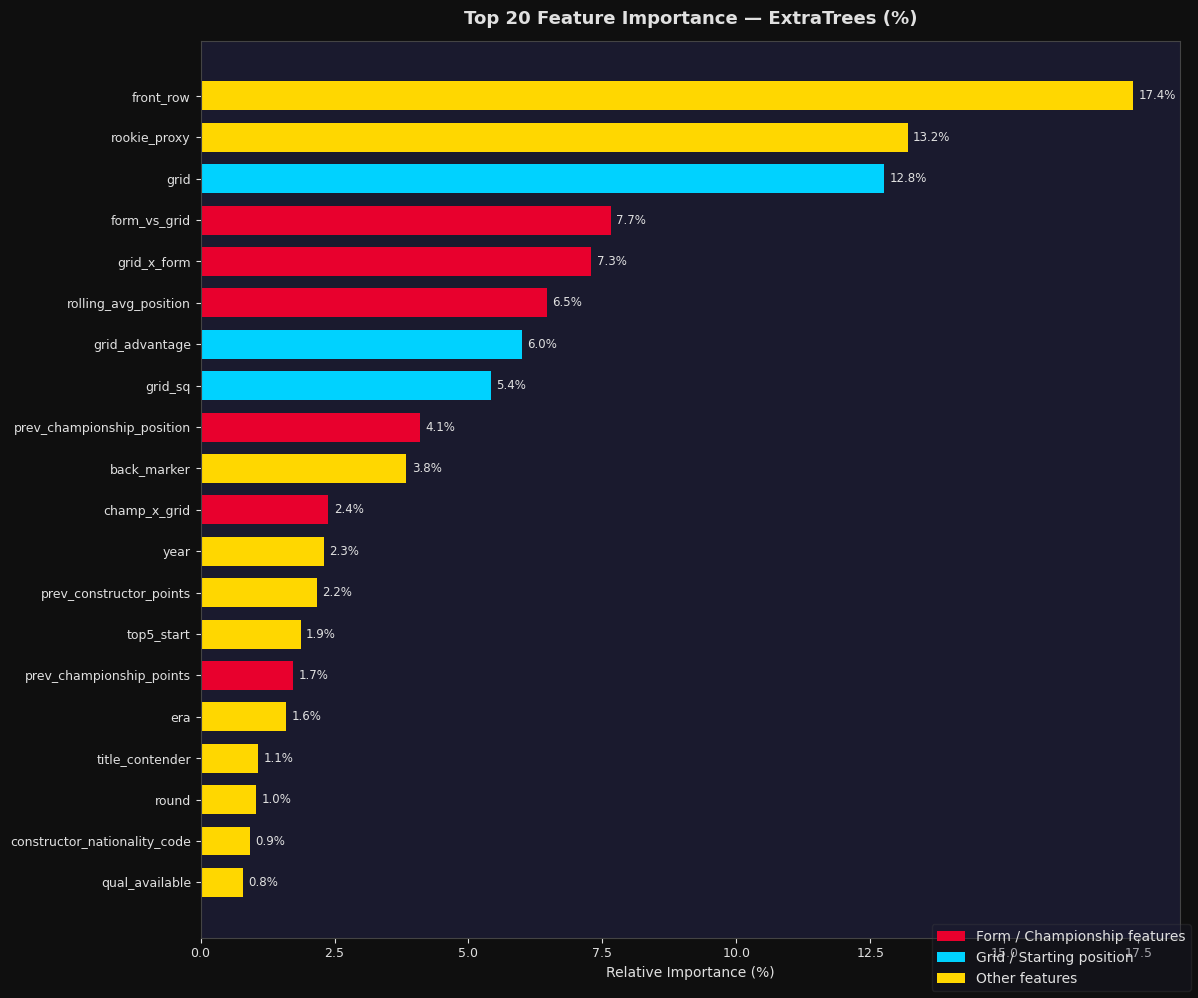

In [10]:
fig, ax = plt.subplots(figsize=(12, 10), facecolor='#0f0f0f')

imp   = pd.Series(fi_et, index=FEATURES)
top20 = imp.nlargest(20).sort_values()
norm  = top20 / top20.sum() * 100

cc = [F1_RED   if any(k in i for k in ['rolling','form','champ','wins']) else
      ACCENT if 'grid' in i else F1_GOLD
      for i in norm.index]

ax.barh(norm.index, norm.values, color=cc, edgecolor='none', height=0.7)
ax.set_title("Top 20 Feature Importance — ExtraTrees (%)",
             fontweight='bold', pad=12)
ax.set_xlabel("Relative Importance (%)")
ax.set_facecolor('#1a1a2e')
ax.tick_params(labelsize=9)
for i, v in enumerate(norm.values):
    ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=8.5, color='#e0e0e0')

fig.legend(
    handles=[Patch(facecolor=F1_RED,   label='Form / Championship features'),
             Patch(facecolor=ACCENT,   label='Grid / Starting position'),
             Patch(facecolor=F1_GOLD,  label='Other features')],
    loc='lower right', fontsize=10, framealpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=130, facecolor='#0f0f0f')
plt.show()

## 10. 🏁 Submission Generation

In [11]:
# Clip to valid F1 range [1, 20] — fractional values are allowed
final_pred = np.clip(test_ens, 1, 20)

submission = sub.copy()
submission['finishing_position'] = final_pred
submission.to_csv("submission.csv", index=False)

print("✅ submission.csv saved!")
print(f"\n{'='*45}")
print(f"{'  Submission Preview':^45}")
print(f"{'='*45}")
print(submission.head(10).to_string(index=False))
print(f"{'='*45}")
print(f"\nPrediction stats:")
print(f"  Min  : {final_pred.min():.2f}")
print(f"  Max  : {final_pred.max():.2f}")
print(f"  Mean : {final_pred.mean():.2f}")
print(f"  Std  : {final_pred.std():.2f}")

✅ submission.csv saved!

              Submission Preview             
      id  finishing_position
1098_846           10.102514
1098_857           15.705790
1098_848           13.127535
1098_858           13.821207
1098_832            6.839920
1098_844            4.412070
1098_815            4.576527
1098_830            3.489350
1098_822           11.771571
1098_855           13.224225

Prediction stats:
  Min  : 1.01
  Max  : 17.01
  Mean : 10.59
  Std  : 3.78


### 10.1 Prediction Distribution Check

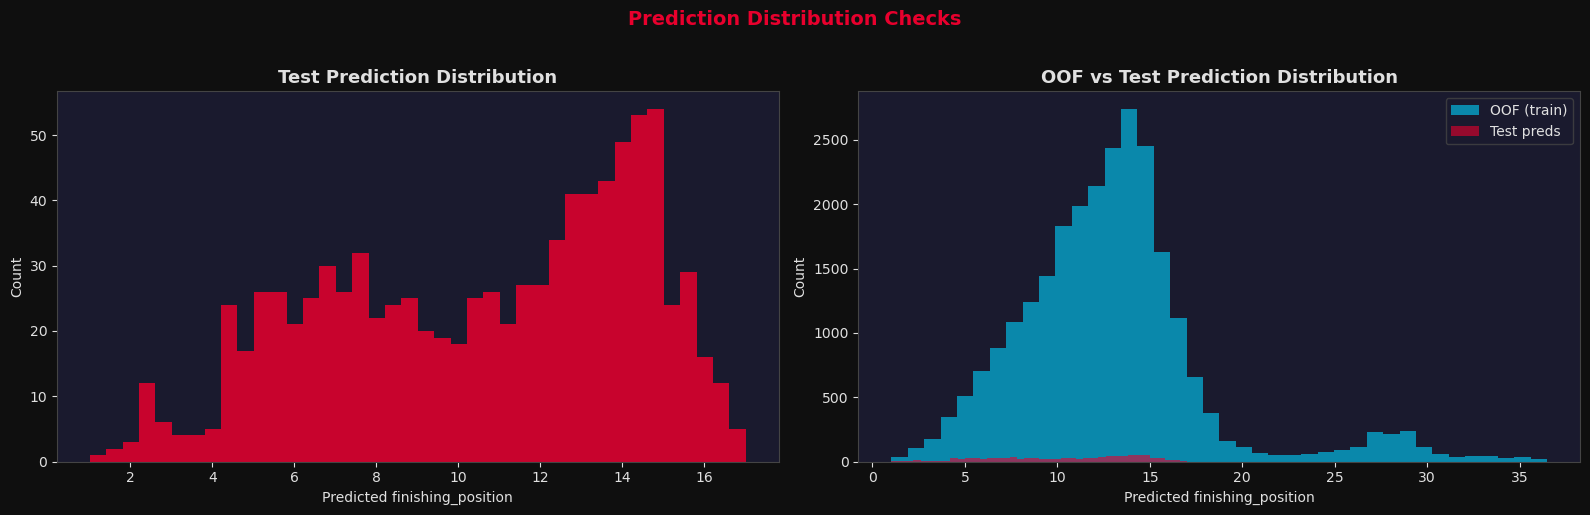

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#0f0f0f')

axes[0].hist(final_pred, bins=40, color=F1_RED, edgecolor='none', alpha=0.85)
axes[0].set_title("Test Prediction Distribution", fontweight='bold')
axes[0].set_xlabel("Predicted finishing_position"); axes[0].set_ylabel("Count"); axes[0].set_facecolor('#1a1a2e')

axes[1].hist(oof_ens,   bins=40, color=ACCENT,  alpha=0.6, label='OOF (train)', edgecolor='none')
axes[1].hist(final_pred, bins=40, color=F1_RED, alpha=0.6, label='Test preds',  edgecolor='none')
axes[1].set_title("OOF vs Test Prediction Distribution", fontweight='bold')
axes[1].set_xlabel("Predicted finishing_position"); axes[1].set_ylabel("Count")
axes[1].legend(); axes[1].set_facecolor('#1a1a2e')

plt.suptitle("Prediction Distribution Checks", fontsize=14, fontweight='bold', color=F1_RED, y=1.02)
plt.tight_layout()
plt.savefig('prediction_distribution.png', bbox_inches='tight', dpi=130, facecolor='#0f0f0f')
plt.show()

## 11. 📋 Summary & Next Steps

---

### ✅ Pipeline Recap

| Step | Detail |
|---|---|
| **EDA** | Target distribution, race/driver counts, Grid→Finish heatmap, pole win rates |
| **Missing Values** | Qualifying imputed from grid-median; pit data from yearly median |
| **Feature Engineering** | +15 new features: grid tiers, form vs grid, era, circuit type, interaction terms |
| **Models** | HistGradientBoosting + ExtraTrees, 5-fold CV, 50/50 ensemble |
| **Evaluation** | OOF MAE, fold stability, residuals, tier-level error breakdown |

---

### 🚀 Ideas to Improve Further

1. **LightGBM / XGBoost** — install via `pip install lightgbm xgboost` for faster training with native MAE objective  
2. **Optuna tuning** — tune `max_leaf_nodes`, `learning_rate`, `n_estimators`  
3. **Driver-circuit interactions** — some drivers historically dominate specific tracks  
4. **Weighted loss by era** — modern F1 (2010+) is structurally different from 1950s  
5. **Race-level normalisation** — ensure each race's predictions rank 1–N correctly  
6. **CatBoost** — handles categoricals natively (driver/constructor IDs)
